In [ ]:
#importing libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#loading dataset
(x_train, y_train),(x_test,y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
#turning labels to one hot encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
y_test.shape

(10000, 10)

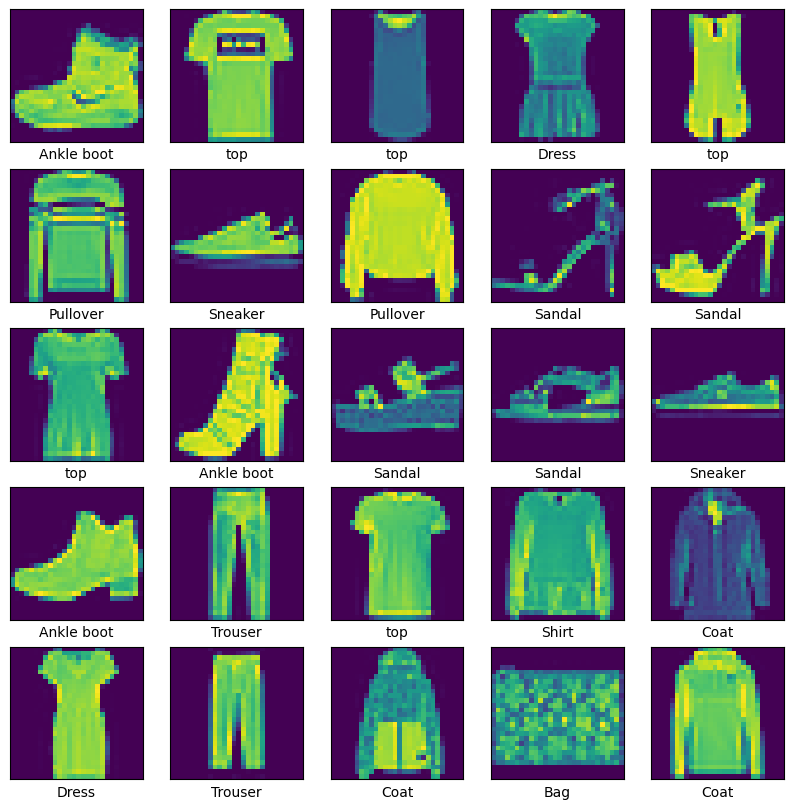

In [ ]:
#visualizing the images
class_names = ['top','Trouser', 'Pullover', 'Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
#predicting first 25 images using loop
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    #removing the grid lines for clear view
    plt.grid(False)
    #now displaying the images
    plt.imshow(x_train[i],interpolation='nearest')
    plt.xlabel(class_names[y_train[i].argmax()])
plt.show()

In [ ]:
#building the model
mod=models.Sequential()
#3 layer and flatten layer at last fully connected layer
mod.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
mod.add(layers.MaxPooling2D((2,2)))
mod.add(layers.Conv2D(64,(3,3),activation='relu'))
mod.add(layers.MaxPooling2D((2,2)))
mod.add(layers.Conv2D(64,(3,3),activation='relu'))
mod.add(layers.Flatten())
mod.add(layers.Dense(64,activation='relu'))
mod.add(layers.Dense(10,activation='softmax'))

In [ ]:
#model comipling
mod.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#model training
mod.fit(x_train, y_train, epochs=5,batch_size=64,validation_data=(x_test,y_test))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - accuracy: 0.7024 - loss: 0.8109 - val_accuracy: 0.8529 - val_loss: 0.4035
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.8667 - loss: 0.3739 - val_accuracy: 0.8734 - val_loss: 0.3504
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.8859 - loss: 0.3124 - val_accuracy: 0.8815 - val_loss: 0.3184
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.8964 - loss: 0.2843 - val_accuracy: 0.8902 - val_loss: 0.3045
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9069 - loss: 0.2593 - val_accuracy: 0.8880 - val_loss: 0.3056


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


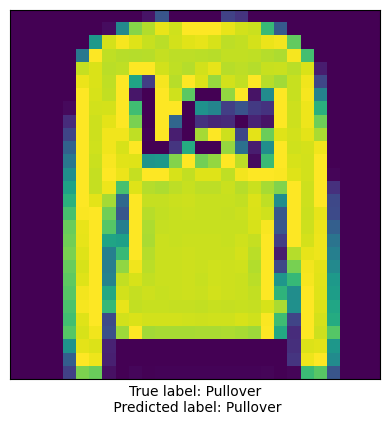

In [ ]:
#predicting a single image
def predict_single_image(index):
  img=x_test[index]
  true_label=np.argmax(y_test[index])
  pred=mod.predict(img.reshape(1,28,28,1))
  pred_label=np.argmax(pred)

  #now visualizing
  plt.imshow(img)
  plt.xticks([])
  plt.yticks([])
  plt.xlabel(f"True label: {class_names[true_label]}\n Predicted label: {class_names[pred_label]}")
  plt.show()

  #sample picture
predict_single_image(1)